In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

In [2]:
region_decline_df = pd.read_csv('./ref_dataset/01_지역소멸지수.csv')
empty_index_df = pd.read_csv('./ref_dataset/02_폐가지수.csv')
visitors_df = pd.read_csv('./ref_dataset/04_방문자수.csv')

w1 = 5
w2 = 3
w3 = -2


In [3]:
temp_df1 = region_decline_df[['도시레벨','소멸위험도']]
temp_df2 = empty_index_df[['도시레벨', '다세대주택','단독주택','폐가지수','페가지수_scaled']]
temp_df3 = visitors_df[['결합행정구역','visitors', 'visitors_scaled']]

temp_df3 = temp_df3.rename(columns={'결합행정구역': '도시레벨'})


In [4]:
merged_df = pd.merge(temp_df1, temp_df2, on='도시레벨', how='inner')
merged_df = pd.merge(merged_df, temp_df3, on='도시레벨', how='inner')

In [5]:
merged_df

,도시레벨,소멸위험도,다세대주택,단독주택,폐가지수,페가지수_scaled,visitors,visitors_scaled
0,경기도 가평군,0.298097,909.0,2370.0,1931.7,0.287306,42095966.5,0.094243
1,경기도 과천시,0.029580,230.0,6.0,73.2,0.010887,42722785.0,0.095801
2,경기도 광명시,0.057613,3322.0,651.0,1452.3,0.216004,90226598.0,0.213921
3,경기도 광주시,0.063612,4094.0,610.0,1655.2,0.246181,122072454.0,0.293107
4,경기도 구리시,0.053793,368.0,288.0,312.0,0.046404,94063235.0,0.223461
...,...,...,...,...,...,...,...,...
180,충청북도 음성군,0.229408,592.0,1068.0,925.2,0.137607,41933661.0,0.093839
181,충청북도 제천시,0.207172,120.0,2503.0,1788.1,0.265948,39717898.5,0.088330
182,충청북도 증평군,0.121168,54.0,342.0,255.6,0.038016,15693429.5,0.028592
183,충청북도 진천군,0.108735,1266.0,603.0,801.9,0.119268,29672485.5,0.063351


In [6]:
merged_df['score'] = w1 * merged_df['소멸위험도'] + w2 * merged_df['페가지수_scaled'] + w3 * merged_df['visitors_scaled']

In [7]:
merged_df

,도시레벨,소멸위험도,다세대주택,단독주택,폐가지수,페가지수_scaled,visitors,visitors_scaled,score
0,경기도 가평군,0.298097,909.0,2370.0,1931.7,0.287306,42095966.5,0.094243,2.163919
1,경기도 과천시,0.029580,230.0,6.0,73.2,0.010887,42722785.0,0.095801,-0.011043
2,경기도 광명시,0.057613,3322.0,651.0,1452.3,0.216004,90226598.0,0.213921,0.508233
3,경기도 광주시,0.063612,4094.0,610.0,1655.2,0.246181,122072454.0,0.293107,0.470390
4,경기도 구리시,0.053793,368.0,288.0,312.0,0.046404,94063235.0,0.223461,-0.038746
...,...,...,...,...,...,...,...,...,...
180,충청북도 음성군,0.229408,592.0,1068.0,925.2,0.137607,41933661.0,0.093839,1.372183
181,충청북도 제천시,0.207172,120.0,2503.0,1788.1,0.265948,39717898.5,0.088330,1.657044
182,충청북도 증평군,0.121168,54.0,342.0,255.6,0.038016,15693429.5,0.028592,0.662702
183,충청북도 진천군,0.108735,1266.0,603.0,801.9,0.119268,29672485.5,0.063351,0.774779


In [8]:
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(merged_df[['score']])
merged_df['final_score'] = scaled_values * 100


In [9]:
result_df = merged_df.sort_values(by='final_score', ascending=False)

#result_df.columns = ['행정구역', '소멸위험', '폐가', '방문자','가중치점수','최종점수']
result_df.columns = ['행정구역', '소멸위험지수_역수처리', '다세대주택', '단독주택','폐가계산값' ,'폐가지수', '방문자', '방문자지수', '가중치점수','최종점수']
result_df.reset_index(drop=True, inplace=True)
result_df.to_csv('./ref_dataset/final_score_weight.csv',index=False, encoding='cp949')
result_df


,행정구역,소멸위험지수_역수처리,다세대주택,단독주택,폐가계산값,폐가지수,방문자,방문자지수,가중치점수,최종점수
0,전라남도 고흥군,0.822905,274.0,5110.0,3659.2,0.544240,16960002.5,0.031741,5.683761,100.000000
1,경상남도 합천군,0.857077,76.0,4036.0,2848.0,0.423589,15409614.5,0.027886,5.500379,97.319401
2,경상북도 의성군,0.875123,133.0,2993.0,2135.0,0.317543,17579415.0,0.033282,5.261680,93.830193
3,경상남도 남해군,0.753431,173.0,4619.0,3285.2,0.488615,17572135.0,0.033264,5.166472,92.438494
4,경상북도 청도군,0.768226,103.0,3740.0,2648.9,0.393976,18344427.5,0.035184,4.952691,89.313533
...,...,...,...,...,...,...,...,...,...,...
180,서울특별시 마포구,0.007318,2219.0,38.0,692.3,0.102967,217273770.0,0.529827,-0.714165,6.477823
181,서울특별시 서초구,0.035464,2759.0,252.0,1004.1,0.149342,276377010.0,0.676789,-0.728235,6.272158
182,서울특별시 영등포구,0.020130,393.0,82.0,175.3,0.026073,208786455.5,0.508723,-0.838578,4.659203
183,서울특별시 송파구,0.029374,2342.0,73.0,753.7,0.112099,277234909.0,0.678922,-0.874678,4.131519


In [14]:
import plotly.graph_objects as go

def plot_result_with_dual_axis(result_df, n=10):
    # 상위 n개 행 선택 (최종점수 기준 내림차순 정렬)
    df_top = result_df.sort_values(by='최종점수', ascending=False).head(n)
    
    # x축: 행정구역
    x = df_top['행정구역']
    
    fig = go.Figure()

    # ✅ 막대그래프: 최종점수
    fig.add_trace(go.Bar(
        x=x,
        y=df_top['최종점수'],
        name='최종점수',
        yaxis='y1'
    ))

    # ✅ 보조 y축 라인그래프들
    for col in ['소멸위험지수_역수처리', '폐가지수', '방문자지수']:
        fig.add_trace(go.Scatter(
            x=x,
            y=df_top[col],
            mode='lines+markers',
            name=col,
            yaxis='y2'
        ))

    # ✅ 레이아웃 설정
    fig.update_layout(
        title=f"상위 {n}개 지역의 최종점수 및 주요 지표 비교",
        xaxis=dict(title='행정구역'),
        yaxis=dict(title='최종점수', side='left'),
        yaxis2=dict(title='스케일링 지표 (0~1)', overlaying='y', side='right'),

    )
    
    return fig


In [20]:
fig = plot_result_with_dual_axis(result_df,30)

In [21]:
fig.write_html('./plot/final_score.html')

In [22]:
fig

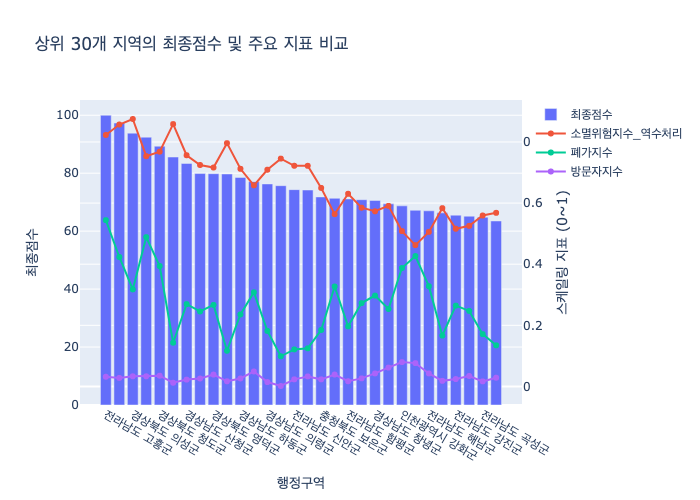

In [23]:
import plotly.io as pio
pio.show(fig, renderer="png")

In [25]:
result_df.iloc[:30]

,행정구역,소멸위험지수_역수처리,다세대주택,단독주택,폐가계산값,폐가지수,방문자,방문자지수,가중치점수,최종점수
0,전라남도 고흥군,0.822905,274.0,5110.0,3659.2,0.544240,16960002.5,0.031741,5.683761,100.000000
1,경상남도 합천군,0.857077,76.0,4036.0,2848.0,0.423589,15409614.5,0.027886,5.500379,97.319401
2,경상북도 의성군,0.875123,133.0,2993.0,2135.0,0.317543,17579415.0,0.033282,5.261680,93.830193
3,경상남도 남해군,0.753431,173.0,4619.0,3285.2,0.488615,17572135.0,0.033264,5.166472,92.438494
4,경상북도 청도군,0.768226,103.0,3740.0,2648.9,0.393976,18344427.5,0.035184,4.952691,89.313533
5,경상북도 봉화군,0.858539,141.0,1314.0,962.1,0.143095,9086294.0,0.012163,4.697655,85.585513
6,경상남도 산청군,0.756527,58.0,2563.0,1811.5,0.269428,13204845.5,0.022404,4.546112,83.370324
7,전라남도 보성군,0.724585,30.0,2344.0,1649.8,0.245378,14669116.0,0.026045,4.306971,79.874667
8,경상북도 영덕군,0.716333,146.0,2500.0,1793.8,0.266796,19867820.0,0.038972,4.304106,79.832789
9,경상북도 청송군,0.796069,145.0,1060.0,785.5,0.116829,10991162.0,0.016900,4.297034,79.729415
